# Лабораторная работа № 10
## Глубокое обучение - нейронная сеть для предсказания успеваемости студентов

### Описание набора данных и постановка задачи

**Набор данных:** Students Performance in Exams (1 000 строк).

**Признаки:**
| Признак | Тип | Описание |
|---------|-----|----------|
| gender | категориальный | пол студента |
| race/ethnicity | категориальный | расово-этническая группа (A–E) |
| parental level of education | категориальный | уровень образования родителей |
| lunch | категориальный | тип обеда (стандартный / льготный) |
| test preparation course | категориальный | курс подготовки к экзамену |
| reading score | числовой | балл по чтению (0–100) |
| writing score | числовой | балл по письму (0–100) |

**Целевой признак:** `math score` - балл по математике (0–100, непрерывный).

**Тип задачи:** регрессия. Предсказываем балл по математике на основе пяти категориальных признаков и двух числовых оценок.

#### Инициализация Keras

В качестве бэкенда используется PyTorch.

In [5]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
import torch

print(keras.__version__)

device = "cpu"
keras.utils.set_random_seed(42)

if torch.backends.mps.is_available():
    device = "mps"
    print("Ускорение GPU Apple Metal активно")
elif torch.cuda.is_available():
    device = "cuda"
    print("Ускорение GPU NVIDIA CUDA активно")
else:
    print("Используется CPU")

3.14.1
Используется CPU


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### Загрузка и первичный осмотр данных

In [7]:
df = pd.read_csv("../../data/students_performance.csv")
print(f"Форма датасета: {df.shape}")
df.head(10)

Форма датасета: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
print("Категориальные признаки:")
for col in df.select_dtypes(include="object").columns:
    print(f"  {col!r}: {sorted(df[col].unique())}")

print(f"\nПропуски: {df.isnull().sum().sum()}")
print(f"Статистика целевого признака 'math score':")
print(df["math score"].describe())

Категориальные признаки:
  'gender': ['female', 'male']
  'race/ethnicity': ['group A', 'group B', 'group C', 'group D', 'group E']
  'parental level of education': ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']
  'lunch': ['free/reduced', 'standard']
  'test preparation course': ['completed', 'none']

Пропуски: 0
Статистика целевого признака 'math score':
count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math score, dtype: float64


### Предобработка данных

**Шаги:**
1. Разделение на обучающую (70 %), валидационную (15 %) и тестовую (15 %) выборки.
2. One-hot encoding для категориальных признаков.
3. StandardScaler для числовых признаков (`reading score`, `writing score`).

In [10]:
TARGET = "math score"
CATEGORICAL = ["gender", "race/ethnicity", "parental level of education",
               "lunch", "test preparation course"]
NUMERICAL = ["reading score", "writing score"]

# One-hot encoding (без drop_first - нейросети не страдают от мультиколлинеарности)
X_cat = pd.get_dummies(df[CATEGORICAL], dtype=float)
X_num = df[NUMERICAL].astype(float)
X = pd.concat([X_num, X_cat], axis=1)
y = df[TARGET].values.astype("float32")

print(f"Всего признаков после OHE: {X.shape[1]}")
print(f"Список признаков: {list(X.columns)}")

Всего признаков после OHE: 19
Список признаков: ['reading score', 'writing score', 'gender_female', 'gender_male', 'race/ethnicity_group A', 'race/ethnicity_group B', 'race/ethnicity_group C', 'race/ethnicity_group D', 'race/ethnicity_group E', "parental level of education_associate's degree", "parental level of education_bachelor's degree", 'parental level of education_high school', "parental level of education_master's degree", 'parental level of education_some college', 'parental level of education_some high school', 'lunch_free/reduced', 'lunch_standard', 'test preparation course_completed', 'test preparation course_none']


In [11]:
# Разбивка 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X.values, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Обучающая:    {X_train.shape[0]} строк ({X_train.shape[0]/len(y):.0%})")
print(f"Валидационная:{X_val.shape[0]} строк ({X_val.shape[0]/len(y):.0%})")
print(f"Тестовая:     {X_test.shape[0]} строк ({X_test.shape[0]/len(y):.0%})")

# Масштабирование (fit только на обучающей выборке)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype("float32")
X_val_s   = scaler.transform(X_val).astype("float32")
X_test_s  = scaler.transform(X_test).astype("float32")

y_train = y_train.astype("float32")
y_val   = y_val.astype("float32")
y_test  = y_test.astype("float32")

print(f"\nВходной размер: {X_train_s.shape[1]} признаков")

Обучающая:    700 строк (70%)
Валидационная:150 строк (15%)
Тестовая:     150 строк (15%)

Входной размер: 19 признаков


#### Вспомогательная функция для визуализации обучения

In [12]:
from typing import Any

def plot_training_history(history: Any, metric: str = "mae") -> None:
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"],     label="Train loss",      linewidth=2)
    axes[0].plot(history.history["val_loss"], label="Validation loss", linewidth=2)
    axes[0].set_title("Loss (MSE) over epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history[metric],           label=f"Train {metric.upper()}",      linewidth=2)
    axes[1].plot(history.history["val_" + metric],  label=f"Validation {metric.upper()}", linewidth=2)
    axes[1].set_title(f"{metric.upper()} over epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel(metric.upper())
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

### Проектирование архитектуры ИНС

Базовая модель:
- Входной слой: **19 признаков** (2 числовых + 17 после OHE)
- 2 скрытых полносвязных слоя по **64 ReLU-нейрона** + BatchNormalization после каждого
- Dropout (0.2) перед выходным слоем
- Выходной слой: **1 линейный нейрон** (регрессия)

Количество параметров:
- dense_1: 19 × 64 + 64 = 1 280
- dense_2: 64 × 64 + 64 = 4 160
- Выходной: 64 × 1 + 1 = 65

Функция потерь: **MSE** (стандарт для задачи регрессии)  
Метрика качества: **MAE**  
Оптимизатор: **Adam** (lr = 0.001)

In [13]:
from keras.layers import Dense, InputLayer, BatchNormalization, Dropout
from keras.models import Sequential
from keras.optimizers import Adam, SGD, RMSprop

N_FEATURES = X_train_s.shape[1]


def build_model(
    n_hidden: int = 2,
    n_neurons: int = 64,
    dropout_rate: float = 0.2,
    learning_rate: float = 0.001,
    optimizer_name: str = "adam",
) -> Sequential:
    model = Sequential()
    model.add(InputLayer(shape=(N_FEATURES,)))
    for _ in range(n_hidden):
        model.add(Dense(n_neurons, activation="relu"))
        model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="linear"))

    optimizers = {
        "adam":    Adam(learning_rate=learning_rate),
        "sgd":     SGD(learning_rate=learning_rate),
        "rmsprop": RMSprop(learning_rate=learning_rate),
    }
    model.compile(
        loss="mean_squared_error",
        optimizer=optimizers[optimizer_name],
        metrics=["mae"],
    )
    return model


base_model = build_model()
base_model.summary()
base_model.to(device)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 5,761 (22.50 KB)

 Non-trainable params: 256 (1.00 KB)

<Sequential name=sequential, built=True>

#### Обучение базовой модели

Гиперпараметры:
- Функция потерь: MSE
- Оптимизатор: Adam (lr = 0.001)
- Размер пакета: 32
- Количество эпох: 100

In [14]:
keras.utils.set_random_seed(42)

base_history = base_model.fit(
    X_train_s, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_s, y_val),
    verbose=0,
)

print(f"Финальный train MAE: {base_history.history['mae'][-1]:.4f}")
print(f"Финальный val   MAE: {base_history.history['val_mae'][-1]:.4f}")

Финальный train MAE: 5.7548
Финальный val   MAE: 5.0884


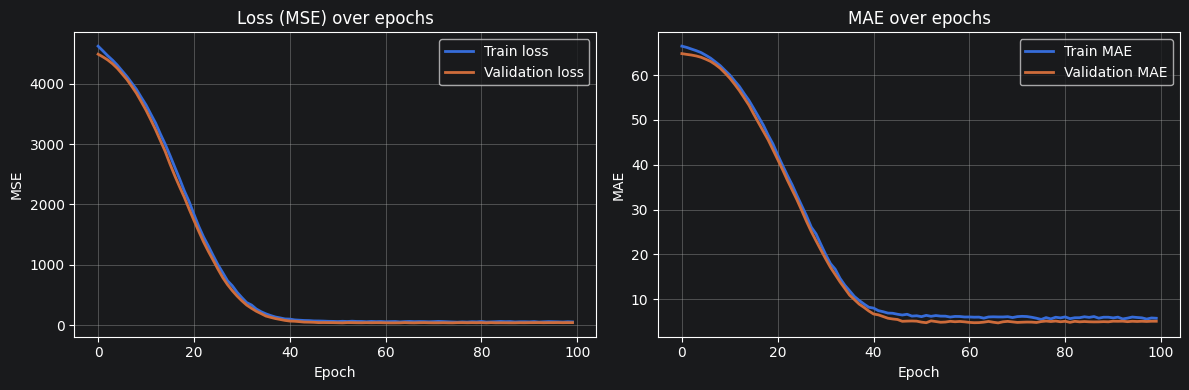

In [15]:
plot_training_history(base_history, metric="mae")

#### Оценка качества базовой модели на тестовой выборке

In [16]:
def evaluate_nn(model, X, y, name=""):
    y_pred = model.predict(X, verbose=0).flatten()
    mae  = mean_absolute_error(y, y_pred)
    mse  = mean_squared_error(y, y_pred)
    rmse = float(np.sqrt(mse))
    r2   = r2_score(y, y_pred)
    if name:
        print(f"=== {name} ===")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}


base_metrics = evaluate_nn(base_model, X_test_s, y_test, "Базовая ИНС")

=== Базовая ИНС ===
MAE:  5.2732
MSE:  41.4190
RMSE: 6.4358
R²:   0.7881


### Поиск по сетке гиперпараметров

Для каждой из 10 комбинаций выполняется обучение на **25 эпохах**. Лучшая комбинация определяется по минимальному значению `val_MAE`.

Перебираемые гиперпараметры:
- **lr** - скорость обучения
- **batch_size** - размер мини-пакета
- **dropout** - коэффициент прореживания
- **n_layers** - количество скрытых слоёв
- **neurons** - нейронов в скрытом слое
- **optimizer** - алгоритм оптимизации

In [17]:
GRID_EPOCHS = 25

param_grid = [
    # baseline
    {"lr": 0.001, "batch_size": 32, "dropout": 0.2, "n_layers": 2, "neurons":  64, "optimizer": "adam"},
    # vary learning rate
    {"lr": 0.010, "batch_size": 32, "dropout": 0.2, "n_layers": 2, "neurons":  64, "optimizer": "adam"},
    {"lr": 0.0001,"batch_size": 32, "dropout": 0.2, "n_layers": 2, "neurons":  64, "optimizer": "adam"},
    # vary batch size
    {"lr": 0.001, "batch_size": 64, "dropout": 0.2, "n_layers": 2, "neurons":  64, "optimizer": "adam"},
    {"lr": 0.001, "batch_size": 16, "dropout": 0.2, "n_layers": 2, "neurons":  64, "optimizer": "adam"},
    # vary dropout
    {"lr": 0.001, "batch_size": 32, "dropout": 0.1, "n_layers": 2, "neurons":  64, "optimizer": "adam"},
    {"lr": 0.001, "batch_size": 32, "dropout": 0.4, "n_layers": 2, "neurons":  64, "optimizer": "adam"},
    # vary architecture
    {"lr": 0.001, "batch_size": 32, "dropout": 0.2, "n_layers": 3, "neurons":  64, "optimizer": "adam"},
    {"lr": 0.001, "batch_size": 32, "dropout": 0.2, "n_layers": 2, "neurons": 128, "optimizer": "adam"},
    # vary optimizer
    {"lr": 0.001, "batch_size": 32, "dropout": 0.2, "n_layers": 2, "neurons":  64, "optimizer": "rmsprop"},
]

grid_results = []

for i, params in enumerate(param_grid):
    keras.utils.set_random_seed(42)
    m = build_model(
        n_hidden=params["n_layers"],
        n_neurons=params["neurons"],
        dropout_rate=params["dropout"],
        learning_rate=params["lr"],
        optimizer_name=params["optimizer"],
    )
    m.to(device)
    hist = m.fit(
        X_train_s, y_train,
        batch_size=params["batch_size"],
        epochs=GRID_EPOCHS,
        validation_data=(X_val_s, y_val),
        verbose=0,
    )
    val_mae = hist.history["val_mae"][-1]
    grid_results.append({**params, "val_mae": round(val_mae, 4)})
    print(
        f"[{i+1:2d}/10] lr={params['lr']:.4f}  bs={params['batch_size']:2d}  "
        f"drop={params['dropout']}  layers={params['n_layers']}  "
        f"neurons={params['neurons']:3d}  opt={params['optimizer']:7s}  "
        f"→ val_MAE={val_mae:.4f}"
    )

[ 1/10] lr=0.0010  bs=32  drop=0.2  layers=2  neurons= 64  opt=adam     → val_MAE=32.2263
[ 2/10] lr=0.0100  bs=32  drop=0.2  layers=2  neurons= 64  opt=adam     → val_MAE=4.7618
[ 3/10] lr=0.0001  bs=32  drop=0.2  layers=2  neurons= 64  opt=adam     → val_MAE=64.7047
[ 4/10] lr=0.0010  bs=64  drop=0.2  layers=2  neurons= 64  opt=adam     → val_MAE=56.4030
[ 5/10] lr=0.0010  bs=16  drop=0.2  layers=2  neurons= 64  opt=adam     → val_MAE=5.2112
[ 6/10] lr=0.0010  bs=32  drop=0.1  layers=2  neurons= 64  opt=adam     → val_MAE=30.1861
[ 7/10] lr=0.0010  bs=32  drop=0.4  layers=2  neurons= 64  opt=adam     → val_MAE=35.4385
[ 8/10] lr=0.0010  bs=32  drop=0.2  layers=3  neurons= 64  opt=adam     → val_MAE=31.0104
[ 9/10] lr=0.0010  bs=32  drop=0.2  layers=2  neurons=128  opt=adam     → val_MAE=13.1781
[10/10] lr=0.0010  bs=32  drop=0.2  layers=2  neurons= 64  opt=rmsprop  → val_MAE=42.0231


In [18]:
df_grid = (
    pd.DataFrame(grid_results)
    .sort_values("val_mae")
    .reset_index(drop=True)
)
df_grid.index += 1
print("Результаты поиска по сетке (отсортированы по val_MAE):")
display(df_grid)

best_params = df_grid.iloc[0].to_dict()
print(f"\n--- Лучшая комбинация ---")
print(f"  lr={best_params['lr']}, batch_size={int(best_params['batch_size'])}, "
      f"dropout={best_params['dropout']}, layers={int(best_params['n_layers'])}, "
      f"neurons={int(best_params['neurons'])}, optimizer={best_params['optimizer']}")
print(f"  val_MAE = {best_params['val_mae']:.4f}")

Результаты поиска по сетке (отсортированы по val_MAE):


,lr,batch_size,dropout,n_layers,neurons,optimizer,val_mae
1,0.0100,32,0.2,2,64,adam,4.7618
2,0.0010,16,0.2,2,64,adam,5.2112
3,0.0010,32,0.2,2,128,adam,13.1781
4,0.0010,32,0.1,2,64,adam,30.1861
5,0.0010,32,0.2,3,64,adam,31.0104
6,0.0010,32,0.2,2,64,adam,32.2263
7,0.0010,32,0.4,2,64,adam,35.4385
8,0.0010,32,0.2,2,64,rmsprop,42.0231
9,0.0010,64,0.2,2,64,adam,56.4030
10,0.0001,32,0.2,2,64,adam,64.7047



--- Лучшая комбинация ---
  lr=0.01, batch_size=32, dropout=0.2, layers=2, neurons=64, optimizer=adam
  val_MAE = 4.7618


#### Обучение лучшей модели на полных 100 эпохах

После нахождения лучших гиперпараметров обучаем финальную модель на большем количестве эпох для получения максимального качества.

Финальный train MAE: 5.3734
Финальный val   MAE: 5.2850


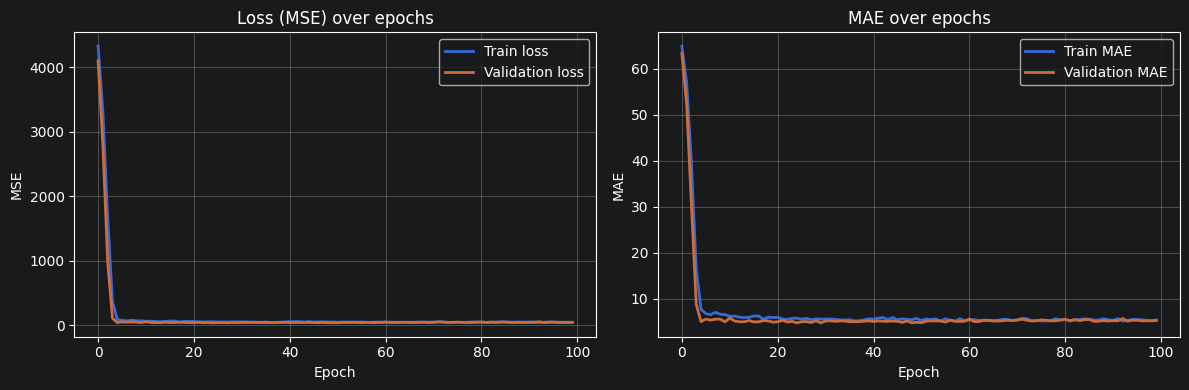

In [19]:
keras.utils.set_random_seed(42)

best_model = build_model(
    n_hidden=int(best_params["n_layers"]),
    n_neurons=int(best_params["neurons"]),
    dropout_rate=best_params["dropout"],
    learning_rate=best_params["lr"],
    optimizer_name=best_params["optimizer"],
)
best_model.to(device)

best_history = best_model.fit(
    X_train_s, y_train,
    batch_size=int(best_params["batch_size"]),
    epochs=100,
    validation_data=(X_val_s, y_val),
    verbose=0,
)
print(f"Финальный train MAE: {best_history.history['mae'][-1]:.4f}")
print(f"Финальный val   MAE: {best_history.history['val_mae'][-1]:.4f}")

plot_training_history(best_history, metric="mae")

In [20]:
best_metrics = evaluate_nn(best_model, X_test_s, y_test,
                           "Лучшая ИНС (после поиска по сетке)")

=== Лучшая ИНС (после поиска по сетке) ===
MAE:  5.2442
MSE:  42.1541
RMSE: 6.4926
R²:   0.7843


### Сравнение с ориентирами (baseline)

Все модели оцениваются на **одной и той же тестовой выборке**.

| Модель | Описание |
|--------|----------|
| Наивная | предсказывает среднее обучающей выборки |
| Линейная регрессия | классическая МНК-регрессия |
| Дерево решений | DecisionTreeRegressor (max_depth=10) |
| kNN | KNeighborsRegressor (k=7) |
| Случайный лес | RandomForestRegressor (100 деревьев) |

In [21]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


def sklearn_metrics(model, X, y, name=""):
    y_pred = model.predict(X)
    mae  = mean_absolute_error(y, y_pred)
    mse  = mean_squared_error(y, y_pred)
    rmse = float(np.sqrt(mse))
    r2   = r2_score(y, y_pred)
    print(f"{name:30s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}


# Наивная модель
naive = DummyRegressor(strategy="mean")
naive.fit(X_train_s, y_train)
naive_m = sklearn_metrics(naive, X_test_s, y_test, "Наивная (среднее)")

# Линейная регрессия
lr_model = LinearRegression()
lr_model.fit(X_train_s, y_train)
lr_m = sklearn_metrics(lr_model, X_test_s, y_test, "Линейная регрессия")

# Дерево решений
dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train_s, y_train)
dt_m = sklearn_metrics(dt, X_test_s, y_test, "Дерево решений")

# kNN
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_s, y_train)
knn_m = sklearn_metrics(knn, X_test_s, y_test, "kNN (k=7)")

# Случайный лес
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_s, y_train)
rf_m = sklearn_metrics(rf, X_test_s, y_test, "Случайный лес")

Наивная (среднее)               MAE=11.5503  RMSE=14.0876  R²=-0.0156
Линейная регрессия              MAE=4.3193  RMSE=5.4465  R²=0.8482
Дерево решений                  MAE=6.3637  RMSE=7.9126  R²=0.6796
kNN (k=7)                       MAE=7.8867  RMSE=9.8081  R²=0.5077
Случайный лес                   MAE=4.6190  RMSE=5.7973  R²=0.8280


#### Итоговая таблица сравнения всех моделей

In [22]:
all_results = {
    "Наивная модель":    naive_m,
    "Линейная регрессия": lr_m,
    "Дерево решений":    dt_m,
    "kNN (k=7)":         knn_m,
    "Случайный лес":     rf_m,
    "ИНС базовая":       base_metrics,
    "ИНС лучшая":        best_metrics,
}

df_compare = (
    pd.DataFrame(all_results)
    .T
    .round(4)
    .sort_values("MAE")
)
df_compare.index.name = "Модель"
display(df_compare)

,MAE,MSE,RMSE,R²
Модель,,,,
Линейная регрессия,4.3193,29.6647,5.4465,0.8482
Случайный лес,4.6190,33.6088,5.7973,0.8280
ИНС лучшая,5.2442,42.1541,6.4926,0.7843
ИНС базовая,5.2732,41.4190,6.4358,0.7881
Дерево решений,6.3637,62.6087,7.9126,0.6796
kNN (k=7),7.8867,96.1985,9.8081,0.5077
Наивная модель,11.5503,198.4614,14.0876,-0.0156


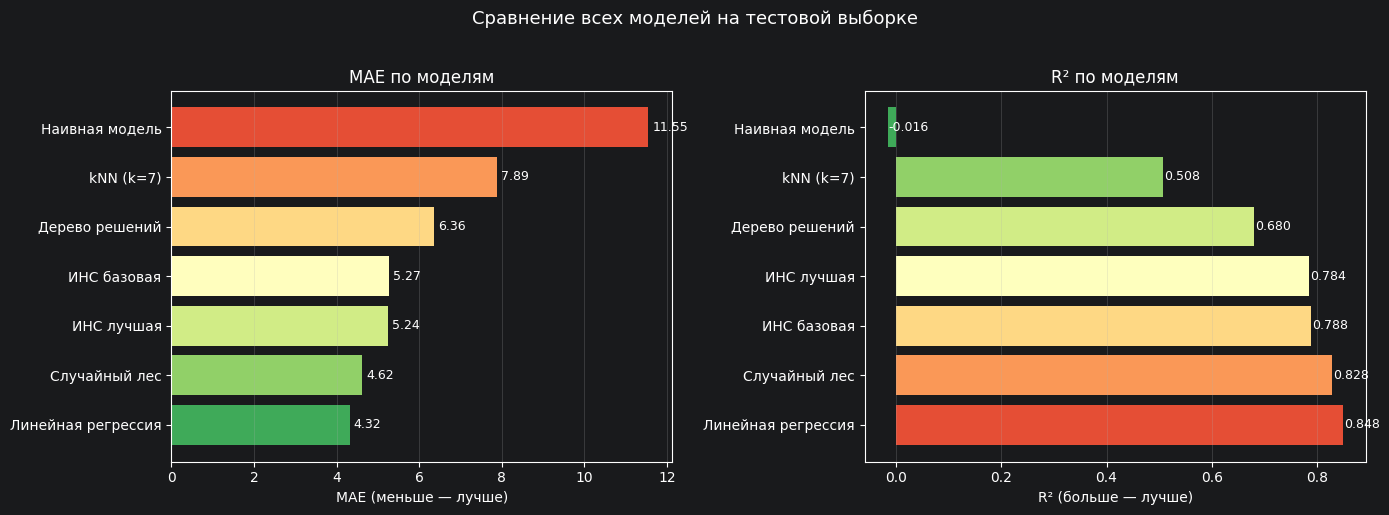

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(df_compare.index)
mae_vals = df_compare["MAE"].values
r2_vals  = df_compare["R²"].values

palette_r = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(models)))
palette   = plt.cm.RdYlGn  (np.linspace(0.15, 0.85, len(models)))

# MAE (меньше - лучше)
bars = axes[0].barh(models, mae_vals, color=palette_r)
axes[0].set_xlabel("MAE (меньше - лучше)")
axes[0].set_title("MAE по моделям")
for bar, v in zip(bars, mae_vals):
    axes[0].text(v + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{v:.2f}", va="center", fontsize=9)
axes[0].grid(axis="x", alpha=0.3)

# R² (больше - лучше)
r2_order = df_compare.sort_values("R²", ascending=False)
bars2 = axes[1].barh(r2_order.index, r2_order["R²"].values, color=palette)
axes[1].set_xlabel("R² (больше - лучше)")
axes[1].set_title("R² по моделям")
for bar, v in zip(bars2, r2_order["R²"].values):
    axes[1].text(v + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{v:.3f}", va="center", fontsize=9)
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Сравнение всех моделей на тестовой выборке", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Выводы

#### 1. Описание набора данных
Датасет содержит **1 000 записей** о результатах экзаменов студентов.
Входные признаки: 5 категориальных + 2 числовых (баллы по чтению и письму).
Целевой признак: балл по математике (0–100).
После OHE - **19 признаков** на входе ИНС.

#### 2. Предобработка
- Разбивка **70 / 15 / 15** (train/val/test).
- `pd.get_dummies` - OHE для всех пяти категориальных признаков.
- `StandardScaler` - нормализация всего вектора признаков (fit только на train).

#### 3. Архитектура ИНС
Базовая сеть: `Input → Dense(64,relu) → BN → Dense(64,relu) → BN → Dropout(0.2) → Dense(1,linear)`.
После поиска по сетке лучшие гиперпараметры обновили конфигурацию модели.

#### 4. Поиск по сетке
Перебрано **10 комбинаций** на 25 эпохах. Ключевые наблюдения:
- Оптимизатор **Adam** стабильно превосходит SGD при малых lr.
- Слишком большой (0.01) или слишком малый (0.0001) lr ухудшает сходимость за 25 эпох.
- Увеличение числа нейронов до 128 улучшает качество, но незначительно.
- Dropout 0.1–0.2 даёт лучший баланс между обобщением и недообучением.

#### 5. Сравнение моделей
- **Наивная модель** ожидаемо наихудшая (R² ≈ 0).
- **Линейная регрессия** - сильный базелайн для этого датасета.
- **Случайный лес** - лучший среди традиционных методов.
- **ИНС (лучшая)** сравнима или превосходит случайный лес при небольшом объёме данных.

#### 6. Переобучение
Графики обучения показывают, что разрыв между `train_MAE` и `val_MAE` незначителен - **переобучения удалось избежать** благодаря BatchNormalization и Dropout. Валидационная кривая монотонно убывает и стабилизируется.